# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

---- Reframing the task------

Used car dealerships often rely on gut feeling or rough market comparisons when pricing their inventory, which can lead to cars being overpriced (and sitting on the lot too long) or underpriced (leaving money on the table). The goal of this project is to help a dealership make smarter, data-driven pricing decisions by predicting the price of a used car based on its characteristics.
To do this, we'll frame the problem as a regression task, where the target variable is the vehicle's price. We'll explore how factors like the car's year, manufacturer, model, condition, mileage (odometer), fuel type, transmission, drive type, and vehicle type relate to price. Before building any models, the data will need to be cleaned and explored — this dataset has a fair number of missing values and likely some messy or unrealistic entries (e.g. suspiciously low or high prices) that need to be handled carefully.
Once the data is in good shape, we'll build and compare a few regression models, using standard evaluation metrics to judge how well each one predicts price. From there, the focus shifts from just "which model performs best" to "what is that model actually telling us" — specifically, which features have the strongest influence on price. The end goal isn't just an accurate model, but practical insight: helping the dealership understand what actually drives a used car's value, so they can price their existing inventory more competitively and make smarter decisions about which cars are worth acquiring in the future.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

### Data Understanding Plan

To understand the dataset and identify potential data-quality issues, I will follow below :

1. Examine the dataset dimensions and preview several observations.
2. Review the column names, data types, and meaning of each variable.
3. Separate the target variable, numerical features, categorical features, and identifier columns.
4. Calculate the number and percentage of missing values in each column.
5. Check for duplicate observations and duplicate vehicle IDs.
6. Examine descriptive statistics for numerical variables.
7. Review the frequency and consistency of categorical values.
8. Explore the distribution of the target variable, `price`.
9. Investigate relationships between price and potential predictors such as year, odometer, manufacturer, condition, and vehicle type.
10. Identify unrealistic values, outliers, inconsistent categories, and features that may not be useful for modeling.

These steps will help determine which vehicle characteristics may influence price and what data preparation will be required before modeling.

In [166]:
#importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error
import os
import warnings
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer, TransformedTargetRegressor
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer


step1: going to load the data and examie the dataset dimensions and preview several observations

### Dataset Note

The dataset is not included in this GitHub repository because it exceeds GitHub's file-size limit. Please download it from the course portal or the original Kaggle source before running the notebook.

In [ ]:
#loading the data from csv
vehicle_data = pd.read_csv("data/vehicles.csv")

#printing the first 5 rows of the dataset
vehicle_data.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [168]:
#examining the dataset dimensions

print('shape of the data: ', vehicle_data.shape)
print('number of columns:', vehicle_data.shape[1])
print('number of rows in dataset:',vehicle_data.shape[0])

shape of the data:  (426880, 18)
number of columns: 18
number of rows in dataset: 426880


step2: Reviewing the column names, data types, and meaning of each variable.

In [169]:
#dataset info
vehicle_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

step3:Separate the target variable, numerical features, categorical features, and identifier columns.

In [170]:
#separating the target variable, numerical features, categorical features, and identifier columns

#target variable
y= 'price'

#numerical features--int/float datatypes from vehicle_data.info()
num_feature=['year','odometer']

#Identifier variable
vehicle_id= ['id']

#categorical variable

cat_feature= vehicle_data.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()



In [171]:
#assigning variable to dataframe

target= vehicle_data[y]

vehicle_ID= vehicle_data[vehicle_id]

x_num= vehicle_data[num_feature]

x_cat= vehicle_data[cat_feature]


#printing the columns
print("Target:", target.shape)
print("Identifier columns:", vehicle_ID.shape)
print("Numerical features:", x_num.shape)
print("Categorical features:", x_cat.shape)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

Target: (426880,)
Identifier columns: (426880, 1)
Numerical features: (426880, 2)
Categorical features: (426880, 14)


step4: Calculating  number and percentage of missing values in each column.

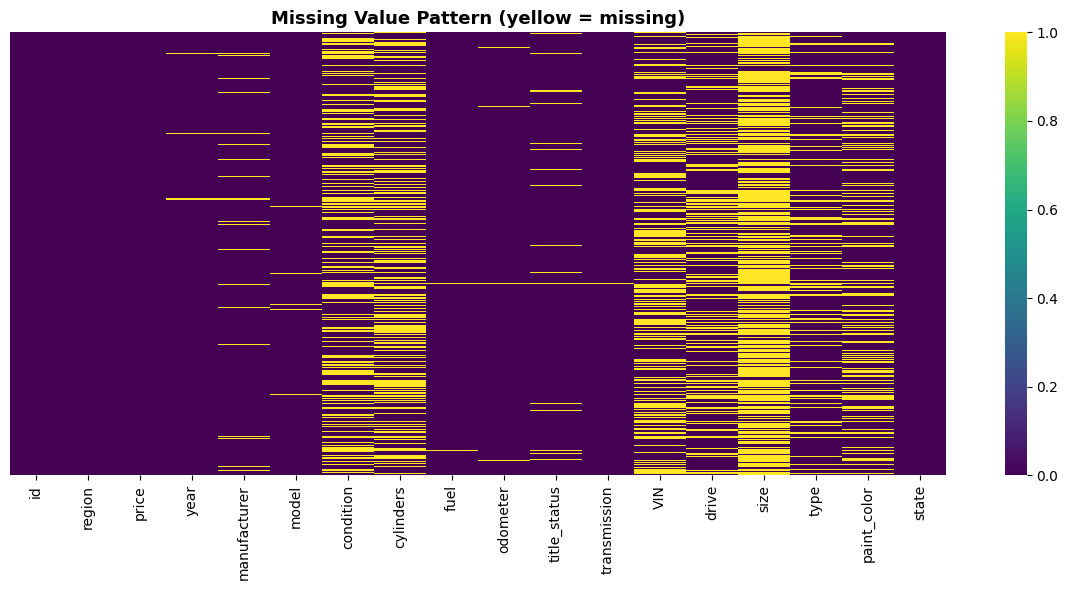

In [172]:
#exploring the number and percentage of missing values in each column.

plt.figure(figsize=(12, 6))
sns.heatmap(vehicle_data.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Value Pattern (yellow = missing)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


-Size is almost entirely yellow,very few lines of purple.

-condition,cylinders,VIN,drive and paint_color have many long horizontal bands of yellow,shows entire stetches of missing rows of these columns.they are not just individual scattered gaps.

-condition and paint_color are patchy and looks like they are correlated.

In [173]:
#%of null values in each column

#lets get % of total null values in each column
missing_perc=vehicle_data.isnull().sum()/len(vehicle_data)*100

print(missing_perc)


id               0.000000
region           0.000000
price            0.000000
year             0.282281
manufacturer     4.133714
model            1.236179
condition       40.785232
cylinders       41.622470
fuel             0.705819
odometer         1.030735
title_status     1.930753
transmission     0.598763
VIN             37.725356
drive           30.586347
size            71.767476
type            21.752717
paint_color     30.501078
state            0.000000
dtype: float64


step 5: Checking for duplicate observations and duplicate vehicle IDs.

In [174]:
# Check fully duplicated observations (identical rows)
duplicate_rows = vehicle_data.duplicated().sum()

# Check duplicate vehicle IDs
duplicate_ids = vehicle_data["id"].duplicated().sum()

print("Number of duplicate observations:", duplicate_rows)
print("Number of duplicate vehicle IDs:", duplicate_ids)

Number of duplicate observations: 0
Number of duplicate vehicle IDs: 0


The dataset was checked for fully duplicated observations and duplicate vehicle IDs. No duplicate rows or repeated vehicle IDs were found. Therefore, each record appears to represent a unique vehicle listing, and no duplicate removal is necessary during data preparation.



step 6: Examining descriptive statistics for numerical variables.

In [175]:
#descriptive statistics for numerical variables
vehicle_data.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


The numerical descriptive statistics revealed potential data-quality issues. The price variable ranges from $0 to approximately $3.74 billion, while its mean is substantially higher than its median, indicating a highly right-skewed distribution with extreme outliers. Vehicle years range from 1900 to 2022, requiring further investigation of unusually old vehicles. Odometer readings range from 0 to 10 million miles, suggesting that some values may be invalid or data-entry errors. Missing values are also present in year and odometer. These issues will be investigated visually during data understanding and handled during the data preparation phase.

In [176]:
numeric_columns = vehicle_data[['price','year','odometer']]

additional_statistics = pd.DataFrame({
    "mode": numeric_columns.mode().iloc[0],
    "range": (
        numeric_columns.max()
        - numeric_columns.min()
    ),
    "IQR": (
        numeric_columns.quantile(0.75)
        - numeric_columns.quantile(0.25)
    ),
    "variance": numeric_columns.var()
})

additional_statistics.round(2).T

,price,year,odometer
mode,0.000000e+00,2017.00,1.000000e+05
range,3.736929e+09,122.00,1.000000e+07
IQR,2.058575e+04,9.00,9.583850e+04
variance,1.484080e+14,89.34,4.574530e+10


Further statistical value suggests,the IQR values provide a more reliable description of the typical data because they are less influenced by extreme observations. The middle 50% of vehicle years covers a nine-year interval, while the middle 50% of odometer readings spans approximately 95,839 miles.These findings support applying reasonable price, year, and odometer limits before modeling.

#box plot for numerical features

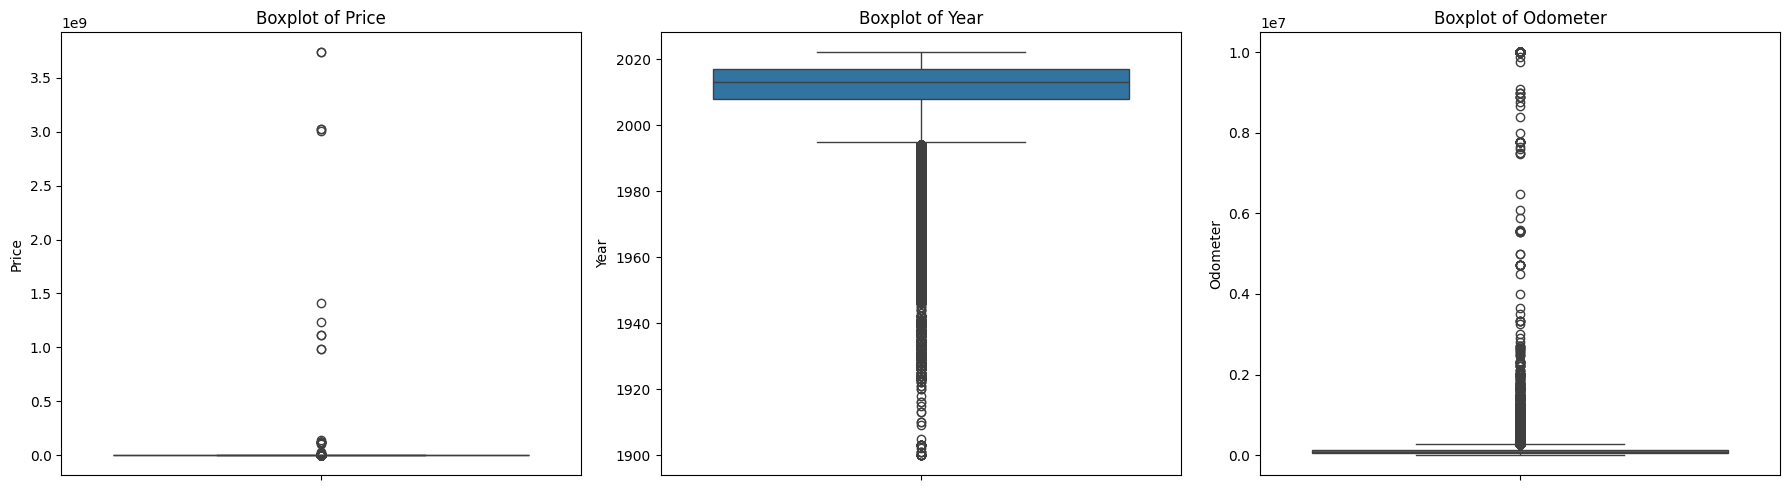

In [177]:
num = ["price", "year", "odometer"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for column, ax in zip(num, axes):
    sns.boxplot(y=vehicle_data[column], ax=ax)
    ax.set_title(f"Boxplot of {column.capitalize()}")
    ax.set_ylabel(column.capitalize())

plt.tight_layout()
plt.show()

Interpretation

Price:  

A few extraordinarily high values—up to approximately $3.7 billion—compress almost the entire box near zero. These are clearly unrealistic for ordinary used cars and likely represent entry errors or placeholder values.

Year:  

Most vehicles are approximately from 2008–2017, while years below roughly 1995 are classified as statistical outliers. However, older years are not necessarily errors; some may be genuine classic or antique vehicles.

Odometer:  

Extremely large readings—up to 10 million miles—compress the main distribution near the bottom. These likely include data-entry errors.

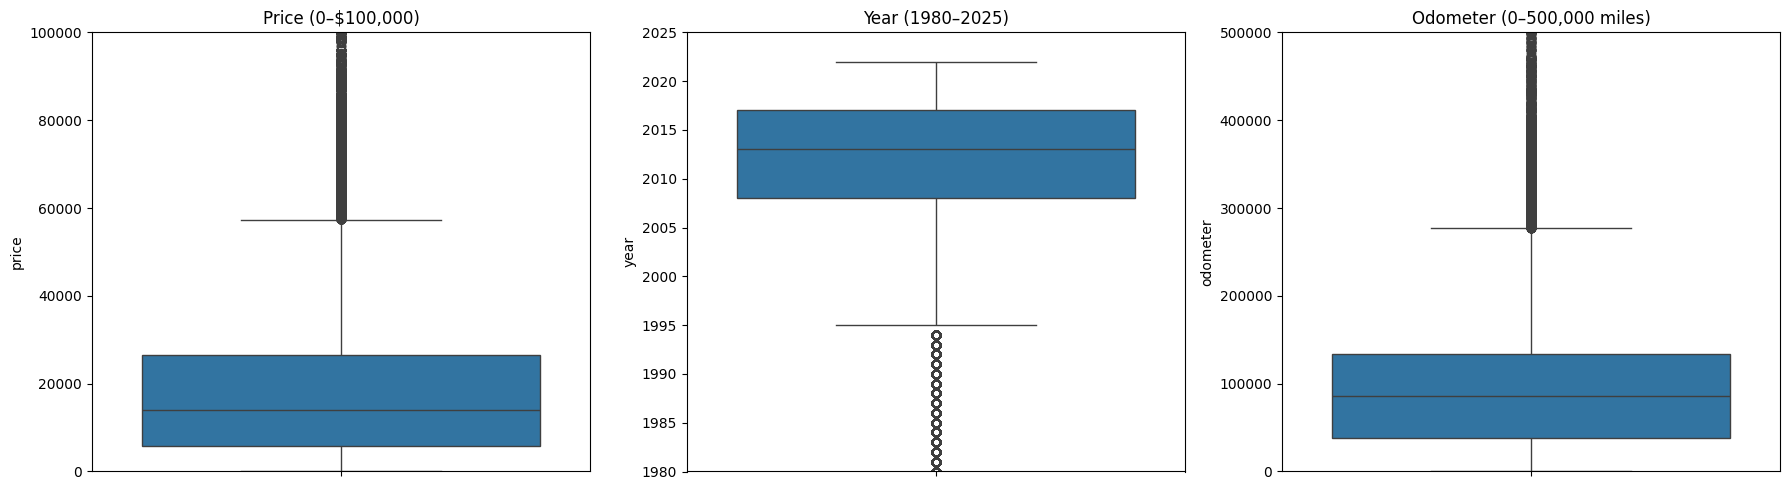

In [178]:
#zooming in to see clear picture in the plot.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=vehicle_data["price"], ax=axes[0])
axes[0].set_ylim(0, 100000)
axes[0].set_title("Price (0–$100,000)")

sns.boxplot(y=vehicle_data["year"], ax=axes[1])
axes[1].set_ylim(1980, 2025)
axes[1].set_title("Year (1980–2025)")

sns.boxplot(y=vehicle_data["odometer"], ax=axes[2])
axes[2].set_ylim(0, 500000)
axes[2].set_title("Odometer (0–500,000 miles)")

plt.tight_layout()
plt.show()

Interpretation

Price

-Median is approximately $14,000.
-The middle 50% of prices is approximately $5,900–$26,500.
-Prices above approximately $57,000 are classified as outliers by the IQR rule.
However, some vehicles legitimately cost more than $57,000, so these should not all be removed automatically.

Year

-Median is 2013.
-The middle 50% of vehicles were manufactured approximately between 2008 and 2017.
-Years before approximately 1995 are flagged as outliers.
-Older vehicles may be genuine classics, so they should be investigated before removal.

Odometer

-Median is approximately 85,548 miles.
-The middle 50% ranges approximately from 37,704 to 133,543 miles.
-Readings above approximately 277,000 miles are classified as outliers.
-Some high-mileage vehicles are valid, but extremely large values—such as millions of miles—are probably erroneous.

lets see how year and odometer are correlated with the price:

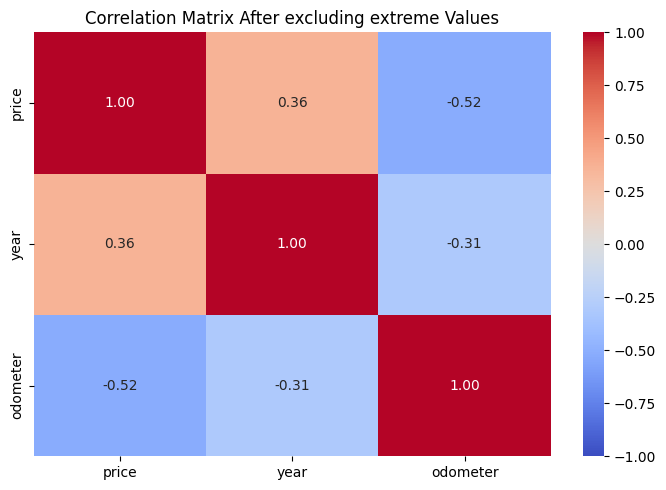

In [179]:
corr_data = vehicle_data[
    vehicle_data["price"].between(500, 100_000)
    & vehicle_data["year"].between(1900, 2022)
    & (
        vehicle_data["odometer"].isna()
        | vehicle_data["odometer"].between(0, 500_000)
    )
][["price", "year", "odometer"]]

correlation_matrix = corr_data.corr().round(2)

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Correlation Matrix After excluding extreme Values")
plt.tight_layout()
plt.show()

The correlation matrix shows that newer vehicles tend to have higher prices (r = 0.36), while vehicles with higher mileage tend to have lower prices (r = −0.52). Odometer has a stronger linear relationship with price than year. Year and odometer are also negatively related (r = −0.31), which is expected because newer vehicles generally have lower mileage. These relationships support including year and odometer-related information in the model, but correlation does not prove causation.

##step 7. Review the frequency and consistency of categorical values.

In [180]:
#inconsistencies in the categorical variable

categorical_summary = []

for column in cat_feature:
    categorical_summary.append({
        "column": column,
        "unique_values": vehicle_data[column].nunique(),
        "missing_values": vehicle_data[column].isna().sum(),
        "missing_percent": vehicle_data[column].isna().mean() * 100,
        "most_frequent": vehicle_data[column].mode().iloc[0],
        "highest_frequency": vehicle_data[column].value_counts().iloc[0]
    })

categorical_summary = pd.DataFrame(categorical_summary)

categorical_summary.round(2)

,column,unique_values,missing_values,missing_percent,most_frequent,highest_frequency
0,region,404,0,0.00,columbus,3608
1,manufacturer,42,17646,4.13,ford,70985
2,model,29649,5277,1.24,f-150,8009
3,condition,6,174104,40.79,good,121456
4,cylinders,8,177678,41.62,6 cylinders,94169
5,fuel,5,3013,0.71,gas,356209
6,title_status,6,8242,1.93,clean,405117
7,transmission,3,2556,0.60,automatic,336524
8,VIN,118246,161042,37.73,1FMJU1JT1HEA52352,261
9,drive,3,130567,30.59,4wd,131904


- model, VIN, and region have high cardinality, with many unique values.
- size has the most missing data at 71.77%.
- condition, cylinders, VIN, drive, and paint_color also contain substantial missing values.
- region and state have no missing values.
- Ford, gas, automatic transmission, sedan, white, and California are the most frequent categories.
- High missingness and high cardinality will need to be handled during data preparation

In [181]:
duplicate_vins = vehicle_data["VIN"].dropna().duplicated().sum()

print("Repeated non-missing VIN observations:", duplicate_vins)

Repeated non-missing VIN observations: 147592


The VIN column behaves as an identifier and contains many missing and repeated values, so it will likely be excluded from modeling.

In [182]:
#for low cardinality feature show every category:

low_cardinality_features = [
    column for column in cat_feature
    if vehicle_data[column].nunique() <= 50
]

for column in low_cardinality_features:
    print(f"\n--- {column.upper()} ---")
    display(vehicle_data[column].value_counts(dropna=False).head(5).to_frame())


--- MANUFACTURER ---


,count
manufacturer,
ford,70985
chevrolet,55064
toyota,34202
honda,21269
nissan,19067



--- CONDITION ---


,count
condition,
NaN,174104
good,121456
excellent,101467
like new,21178
fair,6769



--- CYLINDERS ---


,count
cylinders,
NaN,177678
6 cylinders,94169
4 cylinders,77642
8 cylinders,72062
5 cylinders,1712



--- FUEL ---


,count
fuel,
gas,356209
other,30728
diesel,30062
hybrid,5170
NaN,3013



--- TITLE_STATUS ---


,count
title_status,
clean,405117
NaN,8242
rebuilt,7219
salvage,3868
lien,1422



--- TRANSMISSION ---


,count
transmission,
automatic,336524
other,62682
manual,25118
NaN,2556



--- DRIVE ---


,count
drive,
4wd,131904
NaN,130567
fwd,105517
rwd,58892



--- SIZE ---


,count
size,
NaN,306361
full-size,63465
mid-size,34476
compact,19384
sub-compact,3194



--- TYPE ---


,count
type,
NaN,92858
sedan,87056
SUV,77284
pickup,43510
truck,35279



--- PAINT_COLOR ---


,count
paint_color,
NaN,130203
white,79285
black,62861
silver,42970
blue,31223


The categorical-variable review revealed substantial missing values in several features, particularly size, cylinders, condition, VIN, drive, and paint_color. The model, VIN, and region variables have high cardinality, which may create challenges during encoding. The VIN column behaves as an identifier and contains many missing and repeated values, so it will likely be excluded from modeling. Most lower-cardinality variables contain a manageable number of categories. Their individual values will be reviewed for spelling, capitalization, and labeling inconsistencies before data preparation.



##step 8. Explore the distribution of the target variable, `price`.

In [183]:
#exploring the distribution of price(target variable)

print(vehicle_data['price'].describe())


count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64


Because max prices reaches to billions, normal/avg price range will be suppressed to zero. so tryin histplot in 100k range.

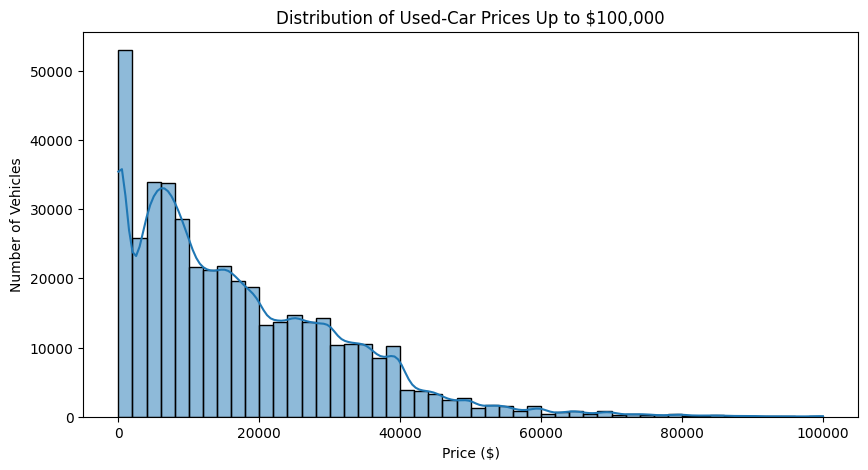

In [184]:
price_for_plot = vehicle_data.loc[
    vehicle_data["price"].between(0, 100_000),
    "price"
]

plt.figure(figsize=(10, 5))

sns.histplot(price_for_plot, bins=50, kde=True)

plt.title("Distribution of Used-Car Prices Up to $100,000")
plt.xlabel("Price ($)")
plt.ylabel("Number of Vehicles")
plt.show()

.The price distribution is strongly skewed to the right.

.Most vehicles are priced below approximately $40,000.

.Only a small number of vehicles are priced close to $100,000.

.There are many vehicles with zero or very low prices. Some of these may be placeholder values rather than actual selling prices.

.The long right tail shows that the dataset contains several expensive vehicles and extreme price outliers.

.These unusual price values will be investigated and handled during the data preparation stage.

.A log transformation of price may be considered later to reduce the skewness before modeling.

In [185]:
#checking extreme prices

print("Zero-price observations:",
      (vehicle_data["price"] == 0).sum())

print("Prices above $100,000:",
      (vehicle_data["price"] > 100_000).sum())

print("Prices above $1 million:",
      (vehicle_data["price"] > 1_000_000).sum())

Zero-price observations: 32895
Prices above $100,000: 655
Prices above $1 million: 53


There are 32,895 vehicles with a price of $0, which may represent missing or placeholder prices. 655 vehicles are priced above $100,000, may be some of them are luxury or vintage cars. 53 vehicles are priced above $1 million, suggesting extreme outliers or possible data-entry errors.
These unusual price values will be investigated and handled during data preparation.

step9: Investigate relationships between price and potential predictors such as year, odometer, manufacturer, condition, and vehicle type.

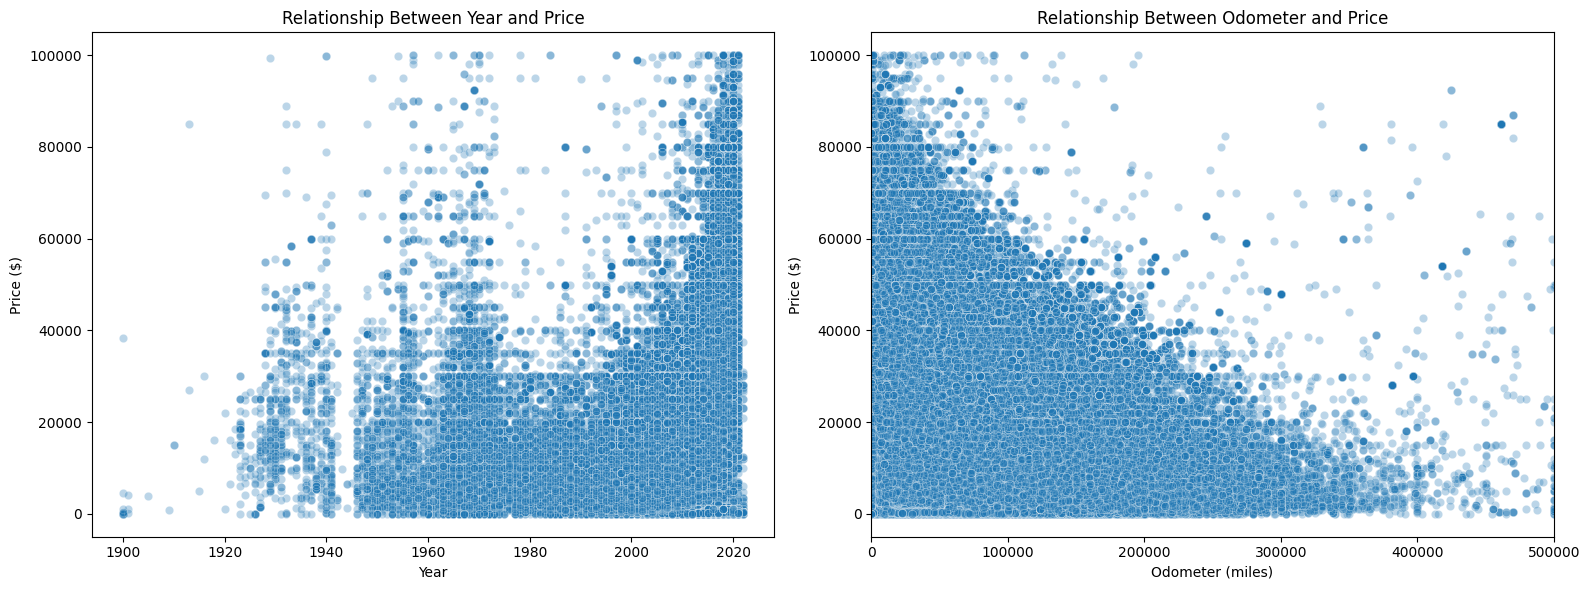

In [186]:
# Selecting  prices up to 100k for visualization only
vehicle = vehicle_data[
    vehicle_data["price"].between(1, 100_000)
]


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=vehicle,
    x="year",
    y="price",
    alpha=0.3,
    ax=axes[0]
)
axes[0].set_title("Relationship Between Year and Price")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Price ($)")

sns.scatterplot(
    data=vehicle,
    x="odometer",
    y="price",
    alpha=0.3,
    ax=axes[1]
)
axes[1].set_xlim(0, 500_000)
axes[1].set_title("Relationship Between Odometer and Price")
axes[1].set_xlabel("Odometer (miles)")
axes[1].set_ylabel("Price ($)")



plt.tight_layout()
plt.show()


#Interpretation:

Newer cars generally have higher prices, while older cars tend to be less expensive. Cars with higher odometer readings usually have lower prices. However, the wide spread suggests that other features, such as manufacturer, condition, and vehicle type, also affect price.

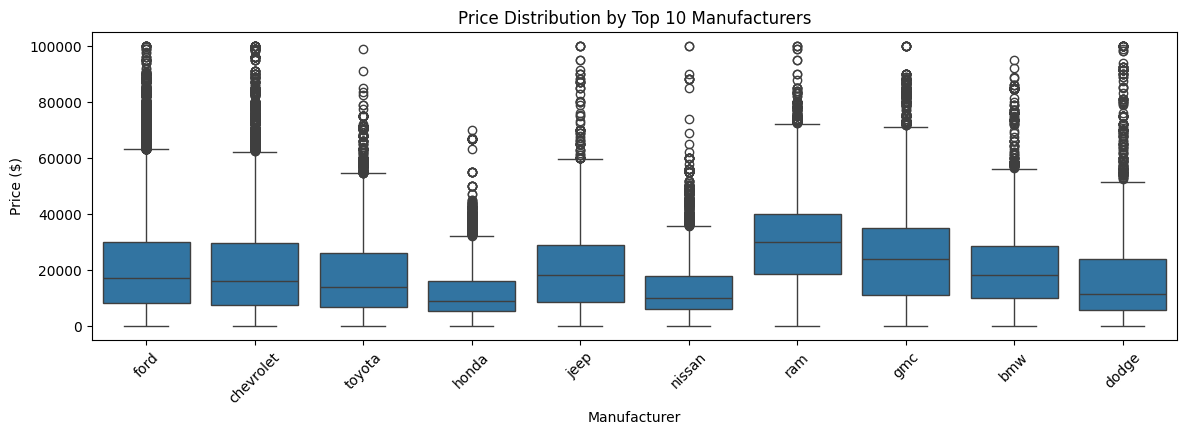

In [187]:
top_manufacturers = (
    vehicle["manufacturer"]
    .value_counts()
    .head(10)
    .index
)

man_data= vehicle[
    vehicle["manufacturer"].isin(top_manufacturers)
]

plt.figure(figsize=(14, 4))

sns.boxplot(
    data=man_data,
    x="manufacturer",
    y="price",
    order=top_manufacturers
)

plt.title("Price Distribution by Top 10 Manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Price ($)")
plt.xticks(rotation=45)
plt.show()

Interpretation:

Newer vehicles generally have higher prices than older vehicles.Vehicles with higher mileage generally have lower prices.
Ram and GMC have the highest median prices among the top ten manufacturers.
Honda and Nissan have relatively lower median prices.
Many outliers are present in all three graphs.
Overall, year, odometer, and manufacturer appear to influence vehicle price.

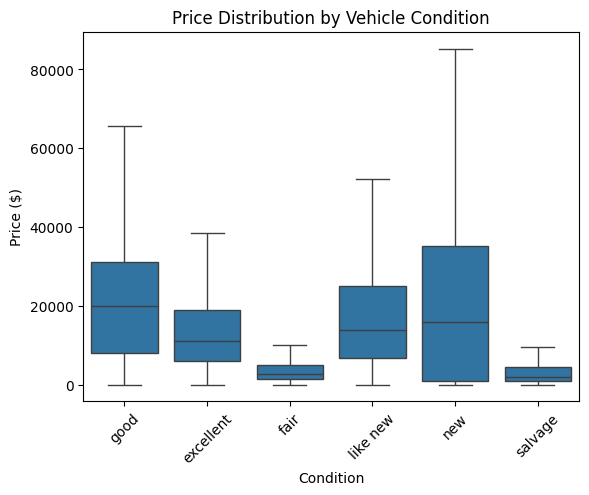

In [188]:
#price by condition:
vehicle_data.groupby("condition")["price"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

sns.boxplot(
    data=vehicle_data,
    x="condition",
    y="price",
    showfliers=False
)

plt.title("Price Distribution by Vehicle Condition")
plt.xlabel("Condition")
plt.ylabel("Price ($)")
plt.xticks(rotation=45)
plt.show()

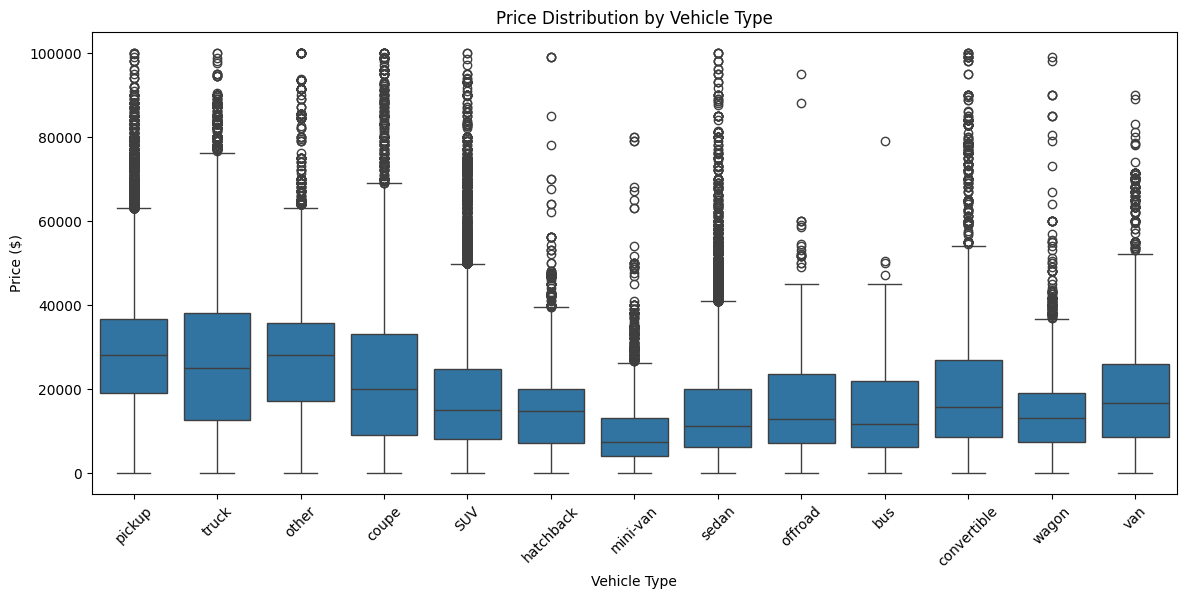

In [189]:
#exploring type categorical variable impact on prize


plt.figure(figsize=(14, 6))

sns.boxplot(
    data=vehicle[['price','type']],
    x="type",
    y="price"
)

plt.title("Price Distribution by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Price ($)")
plt.xticks(rotation=45)
plt.show()

Pickup trucks and vehicles labeled other have the highest median prices.
Trucks and coupes also have relatively high median prices.
Mini-vans have the lowest median price.
Sedans, buses, wagons, and off-road vehicles have lower median prices than pickups and trucks.
Every vehicle type has high-price outliers.
Overall, vehicle type appears to be an important predictor of price.

# Data Quality Findings

- `price`: 32,895 zero values — likely missing/placeholder, not real prices
- 655 prices over $100k, 53 over $1M — possible outliers/errors
- max price ≈ $3.74 billion — clearly unrealistic, needs cleaning
- `odometer`: ranges from 0 to 10 million miles — extreme high values likely data-entry errors
- `year`: ranges 1900–2022 — older years may be classic cars, so flag for review instead of dropping automatically
- no fully duplicated rows or duplicate vehicle IDs found
- categorical values are mostly consistent, but `SUV` is uppercase while other `type` values are lowercase — needs standardizing
- `other` category appears across several columns — low information value
- missing data present in `condition`, `cylinders`, `drive`, `paint_color`, `type`, and especially `size`
- `size` is ~71.77% missing — likely not usable for modeling
- `id`: just a record identifier, no predictive value
- `VIN`: identifier, 37.73% missing, very high cardinality — candidate for removal
- `model`: 29,649 unique values — one-hot encoding would be impractical
- `region`: 404 categories — may overlap with `state`
- **Next step:** address these issues in the Data Preparation phase before modeling

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [190]:
#creating a copy of dataset:

df= vehicle_data.copy()

print("Original dataframe shape:", vehicle_data.shape)
print("Working copy shape:", df.shape)

Original dataframe shape: (426880, 18)
Working copy shape: (426880, 18)


In [191]:
#dropping ID,VIN as they represent individual record not the cjarecteristic of the vehicle. Also dropping size columns because of >70% of missing data

df.drop(columns=["id", "VIN"], inplace=True)
df.drop(columns='size',inplace=True)


In [192]:
# standardizing the categorical columns
categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns

for column in categorical_columns:
    df[column] = (
        df[column]
        .str.strip()
        .str.lower()
    )

In [193]:
#cleaning the target variable 'price'

df_price_count= pd.DataFrame([('vehicle price = 0:', (df['price']==0).sum()),
                      ('vehicle price <500 :', (df["price"] < 500).sum()),
                      ('vehicle price <1000:', (df['price']<1000).sum()),
                      ('vehicle price>100000:',(df['price']>100000).sum()),
                      ('vehicle price>1000000:',(df['price']>1000000).sum())])

df_price_count

,0,1
0,vehicle price = 0:,32895
1,vehicle price <500 :,42094
2,vehicle price <1000:,46315
3,vehicle price>100000:,655
4,vehicle price>1000000:,53


In [194]:
#dropping the rows with vehicle price 0

df=df[~(df['price']==0)].copy()

#dropping rows above 100k price range

df=df[~(df['price']>100000)].copy()

print("min vehicle price: " ,df['price'].min())
print('max vehicle price: ' ,df['price'].max())
print('df shape:', df.shape)

min vehicle price:  1
max vehicle price:  100000
df shape: (393330, 15)


Data still consists min price of &1 which seems unrealistic or a placeholder, lets deep dive a bit more to find out vehicle count in lower range to decide lower limit of target variable for modelling.

In [195]:
price_lower_lim = pd.DataFrame([
    ("price from 1 to 99", df["price"].between(1, 99).sum()),
    ("price between 100 to 499", (df["price"].between(100, 499).sum())),
    ("price below 500", (df["price"] < 500).sum()),
    ("price below 1,000", (df["price"] < 1_000).sum())
], columns=["price_range", "count"])

price_lower_lim

,price_range,count
0,price from 1 to 99,3327
1,price between 100 to 499,5872
2,price below 500,9199
3,"price below 1,000",13420


In [196]:
#dropping rows below &500 , setting lower threshhold to 500

df= df[~(df['price']<500)].copy()
print("min vehicle price: " ,df['price'].min())
print('max vehicle price: ' ,df['price'].max())
print('df shape:', df.shape)

min vehicle price:  500
max vehicle price:  100000
df shape: (384131, 15)


In [197]:
#cleaning numerical features"

#---Year: removing year>2022 and year<1900 , dropping NaN row , which are few (.28%)
df= df[df['year'].between(1900,2022)].copy()

#removing high odometer outliers:

df = df[df["odometer"].isna()| df["odometer"].between(0, 500000)].copy()

In [198]:
#handling high cardinality feature 'model' column(has >29k diffrent column, one hot encoding make unnecessary complex dataset)

df.drop(columns="model", inplace=True)

In [199]:
#creating another column to determine the age of the car
df = df.dropna(subset=["year"]).copy()

df["vehicle_age"] = 2022 - df["year"]
df.drop(columns="year", inplace=True)

In [200]:
#Verifying the prepared data.
print("Cleaned shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))

print("\nPrice range:")
print(df["price"].agg(["min", "median", "max"]))

print("\nVehicle age range:")
print(df["vehicle_age"].agg(["min", "median", "max"]))

print("\nOdometer range:")
print(df["odometer"].agg(["min", "median", "max"]))

Cleaned shape: (381815, 14)

Missing values:
cylinders       156317
condition       143702
drive           116120
paint_color     110756
type             82269
manufacturer     13843
title_status      6693
fuel              2331
odometer          2052
transmission      1749
region               0
price                0
state                0
vehicle_age          0
dtype: int64

Price range:
min          500.0
median     15896.0
max       100000.0
Name: price, dtype: float64

Vehicle age range:
min         0.0
median      9.0
max       122.0
Name: vehicle_age, dtype: float64

Odometer range:
min            0.0
median     87801.0
max       500000.0
Name: odometer, dtype: float64


In [201]:
# Still many missing values, lets split the data now in training and test dataset to avoid data leakage  before imputing missing values 
# with median or mode

X = df.drop(columns="price")
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train = X_train.copy()
X_test = X_test.copy()

In [202]:
#Fill the missing values with median,mode or unknown

#---odometer----
odometer_median = X_train["odometer"].median()

X_train["odometer"] = X_train["odometer"].fillna(odometer_median)
X_test["odometer"] = X_test["odometer"].fillna(odometer_median)

#-----manufacturer,title_status,fuel,transmission-missing values in low number---

low_missing_columns = [
    "manufacturer",
    "title_status",
    "fuel",
    "transmission"
]

for column in low_missing_columns:
    training_mode = X_train[column].mode()[0]

    X_train[column] = X_train[column].fillna(training_mode)
    X_test[column] = X_test[column].fillna(training_mode)

#----cylinders,condition,drive,paint_color,type- high missing value---
high_missing_columns=['cylinders','condition','drive','paint_color','type']

X_train[high_missing_columns] = (
    X_train[high_missing_columns].fillna("unknown")
)

X_test[high_missing_columns] = (
    X_test[high_missing_columns].fillna("unknown")
)    

In [203]:
print("Training missing values:", X_train.isna().sum().sum())
print("Testing missing values:", X_test.isna().sum().sum())

Training missing values: 0
Testing missing values: 0


In [204]:
num_features = ["odometer", "vehicle_age"]

cat_features = [
    "region",
    "manufacturer",
    "condition",
    "cylinders",
    "fuel",
    "title_status",
    "transmission",
    "drive",
    "type",
    "paint_color",
    "state"
]

print("Missing values in X_train:", X_train.isna().sum().sum())
print("Missing values in X_test:", X_test.isna().sum().sum())

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Missing values in X_train: 0
Missing values in X_test: 0
X_train shape: (305452, 13)
X_test shape: (76363, 13)
y_train shape: (305452,)
y_test shape: (76363,)


##copy of the original dataset was created before cleaning.

- The identifier columns id and VIN were removed because they are not useful predictors of price.
- The size column was removed because approximately 72% of its values were missing.
- The model column was removed because it had too many unique categories.
- Vehicle prices below $500 and above $100,000 were removed to reduce placeholder values and extreme outliers.
- Odometer values above 500,000 miles were removed as unrealistic.
- Categorical values were standardized to lowercase and extra spaces were removed.
- A new vehicle_age feature was created from the year column.
- The data was split into training and testing sets.
- Missing odometer values were filled using the training-set median.
- Missing categorical values were filled using either "unknown" or the training-set mode.
- The same values learned from the training data were used to clean the test data and prevent data leakage.
- The cleaned dataset is now ready for categorical encoding, scaling, and regression modeling.

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [205]:
#baseline model, lets do one hot encoding for categorical variable


vehicle_transformer = make_column_transformer(
    (
        OneHotEncoder(
            handle_unknown="ignore",
            drop="if_binary"
        ),
        cat_features
    ),
    remainder="passthrough"
)

In [206]:
#create a pipeline

lin_pipe = Pipeline([
    ("transformer", vehicle_transformer),
    ("model", LinearRegression())
])

Evaluation metric:

I picked RMSE as my main way to compare the models. It's basically measures the typical magnitude of prediction errors in dollars, so it's easy to actually understand - like "the model is off by about $X on average" makes sense to a dealer, unlike something in squared dollars.
I also liked that RMSE punishes bigger mistakes more than small ones (since it squares the errors before averaging). In a way it is useful because substantially overpricing or underpricing a vehicle can be costly for a dealership, so I wanted the metric to care more about those big misses.

One thing to note - I used negative MSE as the GridSearchCV scoring metric, not RMSE directly, so I just took the square root of it to get RMSE for reporting.



In [207]:
#fitting baseline model now:

lin_pipe.fit(X_train, y_train)

train_predictions = lin_pipe.predict(X_train)

train_mse = mean_squared_error(y_train, train_predictions)
train_rmse = np.sqrt(train_mse)

print("Training MSE:", train_mse)
print("Training RMSE:", train_rmse)

Training MSE: 89531502.18132132
Training RMSE: 9462.108759749135


In [208]:
ridge_transformer = make_column_transformer(
    (
        OneHotEncoder(
            handle_unknown="ignore",
            drop="if_binary"
        ),
        cat_features
    ),
    (
        StandardScaler(),
        num_features
    ),
    remainder="drop"
)

ridge_pipe = Pipeline([
    ("transformer", ridge_transformer),
    ("ridge", Ridge())
])

In [209]:
ridge_parameters = {
    "ridge__alpha": [0.1, 1, 3, 10, 100]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_parameters,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=1
)

ridge_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...e', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ridge__alpha': [0.1, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed 

In [210]:
best_ridge_alpha = ridge_grid.best_params_["ridge__alpha"]
best_ridge_mse = -ridge_grid.best_score_
best_ridge_rmse = np.sqrt(best_ridge_mse)

print("Best Ridge alpha:", best_ridge_alpha)
print("Best Ridge CV MSE:", best_ridge_mse)
print("Best Ridge CV RMSE:", best_ridge_rmse)

Best Ridge alpha: 3
Best Ridge CV MSE: 81269068.19623335
Best Ridge CV RMSE: 9014.935839828997


In [211]:
ridge_results = pd.DataFrame(ridge_grid.cv_results_)

ridge_summary = ridge_results[
    ["param_ridge__alpha", "mean_test_score", "std_test_score"]
].copy()

ridge_summary["mean_cv_mse"] = -ridge_summary["mean_test_score"]
ridge_summary["mean_cv_rmse"] = np.sqrt(ridge_summary["mean_cv_mse"])

ridge_summary[
    ["param_ridge__alpha", "mean_cv_mse", "mean_cv_rmse"]
].sort_values("mean_cv_rmse")

,param_ridge__alpha,mean_cv_mse,mean_cv_rmse
2,3.0,8.126907e+07,9014.935840
1,1.0,8.127162e+07,9015.077193
0,0.1,8.127544e+07,9015.289354
3,10.0,8.127556e+07,9015.295928
4,100.0,8.149308e+07,9027.351686


In [212]:

baseline_cv_scores = cross_val_score(
    lin_pipe,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

baseline_cv_mse = -baseline_cv_scores.mean()
baseline_cv_rmse = np.sqrt(baseline_cv_mse)

print("Baseline CV MSE:", baseline_cv_mse)
print("Baseline CV RMSE:", baseline_cv_rmse)

Baseline CV MSE: 89566149.14132941
Baseline CV RMSE: 9463.939409216937


In [213]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "CV MSE": [baseline_cv_mse, best_ridge_mse],
    "CV RMSE": [baseline_cv_rmse, best_ridge_rmse]
})

model_comparison.round(2)

,Model,CV MSE,CV RMSE
0,Linear Regression,89566149.14,9463.94
1,Ridge Regression,81269068.20,9014.94


Ridge regression performed better than the baseline linear regression. Its cross-validation RMSE was approximately $9,015 compared with $9,464 for linear regression, an improvement of about 4.7%. This suggests that Ridge regularization helped the model generalize better by controlling the effects of the large number of encoded categorical features.

In [214]:
lasso_pipe = Pipeline([
    ("transformer", ridge_transformer),
    (
        "lasso",
        Lasso(
            max_iter=2000,
            tol=0.01,
            selection="random",
            random_state=42
        )
    )
])

lasso_parameters = {
    "lasso__alpha": [0.3, 0.1, 1]
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=lasso_parameters,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=2
)

lasso_grid.fit(X_train, y_train);

#tried lasso for parameters [0.1, 1, 10, 50, 100] and 0.1 was the best parameter. It was taking too much time so now have changed it to only 3 smaller parameter

In [215]:
best_lasso_alpha = lasso_grid.best_params_["lasso__alpha"]
best_lasso_mse = -lasso_grid.best_score_
best_lasso_rmse = np.sqrt(best_lasso_mse)

print("Best Lasso alpha:", best_lasso_alpha)
print("Best Lasso CV MSE:", best_lasso_mse)
print("Best Lasso CV RMSE:", best_lasso_rmse)

Best Lasso alpha: 0.3
Best Lasso CV MSE: 81254931.60844885
Best Lasso CV RMSE: 9014.151740926533


In [216]:
best_lasso_model = lasso_grid.best_estimator_.named_steps["lasso"]

total_coefficients = len(best_lasso_model.coef_)
selected_coefficients = np.count_nonzero(best_lasso_model.coef_)
removed_coefficients = total_coefficients - selected_coefficients

print("Total coefficients:", total_coefficients)
print("Selected coefficients:", selected_coefficients)
print("Coefficients set to zero:", removed_coefficients)

Total coefficients: 560
Selected coefficients: 427
Coefficients set to zero: 133


In [217]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "CV MSE": [
        baseline_cv_mse,
        best_ridge_mse,
        best_lasso_mse
    ],
    "CV RMSE": [
        baseline_cv_rmse,
        best_ridge_rmse,
        best_lasso_rmse
    ]
})

model_comparison.round(2)

,Model,CV MSE,CV RMSE
0,Linear Regression,89566149.14,9463.94
1,Ridge Regression,81269068.20,9014.94
2,Lasso Regression,81254931.61,9014.15


In [218]:
best_lasso_model = lasso_grid.best_estimator_.named_steps["lasso"]

total_features = len(best_lasso_model.coef_)
selected_features = np.count_nonzero(best_lasso_model.coef_)
removed_features = total_features - selected_features

print("Total features:", total_features)
print("Selected features:", selected_features)
print("Features removed by Lasso:", removed_features)

Total features: 560
Selected features: 427
Features removed by Lasso: 133


Lasso selected 427 of the 560 encoded features and set 133 coefficients to zero, removing approximately 23.75% of the features. Its cross-validation RMSE was slightly lower than Ridge, but the difference was negligible. Lasso produced a somewhat simpler model, while Ridge achieved almost identical predictive performance with a shorter training time.

now lets try polynomial ridge model and see if it performs better.

In [219]:
#creating a numerical pipeline

poly_numeric_pipeline = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scale", StandardScaler())
])

poly_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="if_binary"
            ),
            cat_features
        ),
        (
            "num",
            poly_numeric_pipeline,
            num_features
        )
    ]
)

poly_ridge_pipeline = Pipeline([
    ("preprocessor", poly_preprocessor),
    ("model", Ridge())
])

In [220]:
[
    name for name in poly_ridge_pipeline.get_params().keys()
    if "degree" in name
]

['preprocessor__num__poly__degree']

In [221]:
poly_parameters = {
    "preprocessor__num__poly__degree": [2, 3],
    "model__alpha": [0.1, 1, 3, 10]
}

poly_grid = GridSearchCV(
    estimator=poly_ridge_pipeline,
    param_grid=poly_parameters,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=2
)

poly_grid.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.1, 1, ...], 'preprocessor__num__poly__degree': [2, 3]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_gri

In [222]:
best_poly_degree = poly_grid.best_params_[
    "preprocessor__num__poly__degree"
]

best_poly_alpha = poly_grid.best_params_["model__alpha"]
best_poly_mse = -poly_grid.best_score_
best_poly_rmse = np.sqrt(best_poly_mse)

print("Best polynomial degree:", best_poly_degree)
print("Best alpha:", best_poly_alpha)
print("Polynomial Ridge CV MSE:", best_poly_mse)
print("Polynomial Ridge CV RMSE:", best_poly_rmse)

Best polynomial degree: 3
Best alpha: 1
Polynomial Ridge CV MSE: 64711359.004803635
Polynomial Ridge CV RMSE: 8044.337076776658


In [223]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Polynomial Ridge"
    ],
    "CV MSE": [
        baseline_cv_mse,
        best_ridge_mse,
        best_lasso_mse,
        best_poly_mse
    ],
    "CV RMSE": [
        baseline_cv_rmse,
        best_ridge_rmse,
        best_lasso_rmse,
        best_poly_rmse
    ]
})

model_comparison.sort_values("CV RMSE").round(2)

,Model,CV MSE,CV RMSE
3,Polynomial Ridge,64711359.00,8044.34
2,Lasso Regression,81254931.61,9014.15
1,Ridge Regression,81269068.20,9014.94
0,Linear Regression,89566149.14,9463.94


##conclusion:
- Polynomial Ridge had the lowest cross-validation error among all models.
- The best polynomial degree was 3, with a Ridge alpha of 1.
- Its cross-validation RMSE was approximately $8,044.
- This was about 15% lower than the baseline linear regression RMSE.
- The improvement suggests that vehicle age and odometer have nonlinear relationships with price.
- Polynomial Ridge is currently the best model and should be selected for final test-set evaluation.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [224]:

# GridSearchCV already refitted the best model on the full training set
best_model = poly_grid.best_estimator_

test_predictions = best_model.predict(X_test)

test_mse = mean_squared_error(y_test, test_predictions)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, test_predictions)


print("Test MSE:", round(test_mse, 2))
print("Test RMSE:", round(test_rmse, 2))
print("Test MAE:", round(test_mae, 2))


Test MSE: 65153144.35
Test RMSE: 8071.75
Test MAE: 5417.93


The final Polynomial Ridge model had a test RMSE of approximately $8,072 and a test MAE of approximately $5,418. The test RMSE was close to the cross-validation RMSE of $8,044, suggesting that the model generalized well to unseen data. However, the RMSE indicates that some prediction errors were still relatively large.

In [225]:
evaluation_summary = pd.DataFrame({
    "Dataset": ["Cross-validation", "Test"],
    "MSE": [best_poly_mse, test_mse],
    "RMSE": [best_poly_rmse, test_rmse]
    
})

evaluation_summary.round(2)

,Dataset,MSE,RMSE
0,Cross-validation,64711359.00,8044.34
1,Test,65153144.35,8071.75


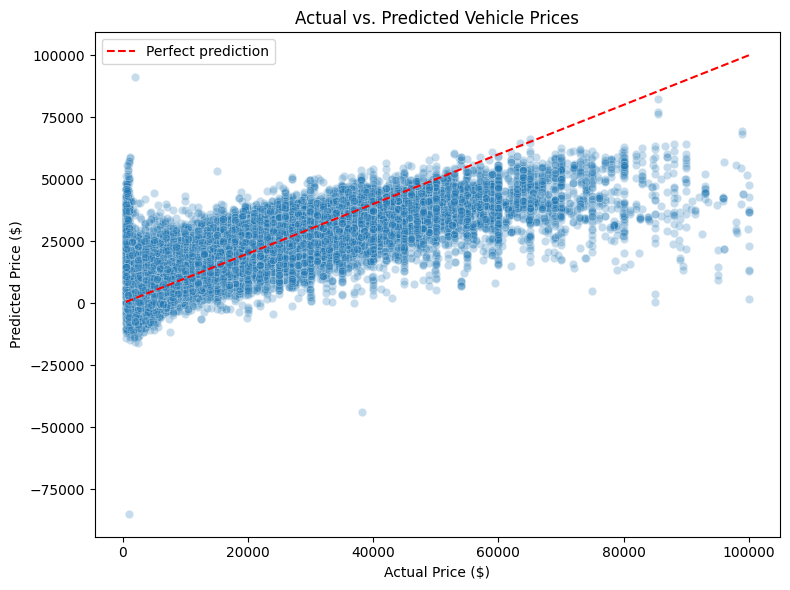

In [226]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=test_predictions,
    alpha=0.25
)

plt.plot(
    [500, 100_000],
    [500, 100_000],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

plt.title("Actual vs. Predicted Vehicle Prices")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.legend()
plt.tight_layout()
plt.show()

The model predicts mid-priced vehicles reasonably well but tends to overpredict cheaper vehicles and underpredict expensive vehicles.

Lets Try Redidual now:

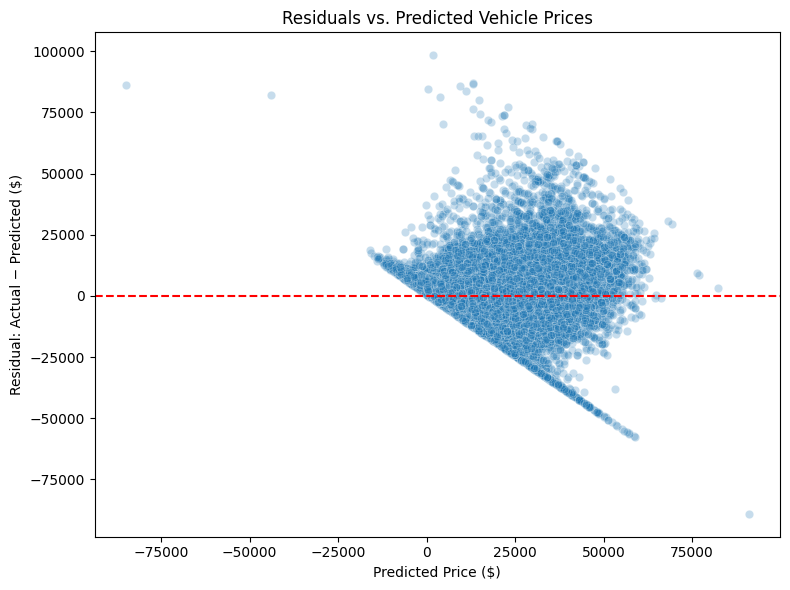

In [227]:
residuals = y_test - test_predictions

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=test_predictions,
    y=residuals,
    alpha=0.25
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residuals vs. Predicted Vehicle Prices")
plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual: Actual − Predicted ($)")
plt.tight_layout()
plt.show()

The residuals are not evenly distributed around zero, suggesting some prediction bias and that the model does not capture all price patterns.

#Extracting model coefficient and interpreting there positive and negative impact on price.

In [228]:
#extracting the model coef:
best_ridge_pipeline = ridge_grid.best_estimator_

feature_names = (
    best_ridge_pipeline
    .named_steps["transformer"]
    .get_feature_names_out()
)

ridge_coefficients = (
    best_ridge_pipeline
    .named_steps["ridge"]
    .coef_
)

coefficient_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": ridge_coefficients
})

coefficient_table["absolute_coefficient"] = (
    coefficient_table["coefficient"].abs()
)

In [229]:
positive_coefficients = (
    coefficient_table
    .sort_values("coefficient", ascending=False)
    .head(15)
)

positive_coefficients[
    ["feature", "coefficient"]
].round(2)

,feature,coefficient
415,onehotencoder__manufacturer_ferrari,41544.90
442,onehotencoder__manufacturer_tesla,15440.02
462,onehotencoder__fuel_diesel,11690.30
454,onehotencoder__cylinders_12 cylinders,9694.21
437,onehotencoder__manufacturer_porsche,9596.68
151,onehotencoder__region_imperial county,8603.49
413,onehotencoder__manufacturer_datsun,7467.76
406,onehotencoder__manufacturer_aston-martin,6244.79
402,onehotencoder__region_yuma,5759.98
309,onehotencoder__region_scottsbluff / panhandle,5460.81


In [230]:
negative_coefficients = (
    coefficient_table
    .sort_values("coefficient")
    .head(15)
)

negative_coefficients[
    ["feature", "coefficient"]
].round(2)

,feature,coefficient
419,onehotencoder__manufacturer_harley-davidson,-12304.72
416,onehotencoder__manufacturer_fiat,-9269.51
433,onehotencoder__manufacturer_mitsubishi,-7962.89
558,standardscaler__odometer,-6424.52
463,onehotencoder__fuel_electric,-6005.27
455,onehotencoder__cylinders_3 cylinders,-5995.18
171,onehotencoder__region_klamath falls,-5953.70
480,onehotencoder__type_bus,-5893.94
440,onehotencoder__manufacturer_saturn,-5806.01
425,onehotencoder__manufacturer_kia,-5507.89


Interpretation:

- Positive coefficients are associated with higher predicted prices, while negative coefficients are associated with lower predicted prices, holding the other model features constant.
- Ferrari had the largest positive coefficient, followed by Tesla and Porsche. This suggests that these manufacturers are associated with higher vehicle prices.
- Diesel fuel, 12-cylinder engines, and vehicles reported as new were also associated with higher predicted prices.
- Harley-Davidson, Fiat, Mitsubishi, Saturn, Kia, and Hyundai had relatively large negative coefficients, indicating lower predicted prices in this dataset.
- Three-cylinder vehicles and buses were also associated with lower predicted prices.
- The odometer coefficient was approximately −$6,425. Because odometer was standardized, a one-standard-deviation increase in mileage was associated with an approximately $6,425 decrease in predicted price, holding the other features constant.
- Regional coefficients show that location also affects listing prices, although regional differences may reflect local inventory, demand, and market conditions.
- These coefficients show associations within this dataset and do not prove that a feature directly causes the price to increase or decrease.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client. 

-------Recommendations to the Dealership---------

Based on this analysis, the following findings may help the dealership make better inventory and pricing decisions:

- Newer vehicles generally have higher prices than older vehicles.
- Vehicles with lower mileage are usually more valuable. The Ridge model showed that higher odometer readings were associated with lower predicted prices.
- Pickup trucks and trucks had higher median prices than sedans, mini-vans, and wagons.
- Ram and GMC had relatively high median prices among the most common manufacturers.
- Luxury manufacturers such as Ferrari, Tesla, and Porsche were associated with higher prices. However, some of these manufacturers had only a small number of listings.
- Diesel vehicles and vehicles with larger engines were also associated with higher prices.
- Vehicle condition affects price, but the condition categories may not always be reported consistently.

Based on these findings, the dealership should consider purchasing newer vehicles with lower mileage. Pickups and trucks may also provide higher resale values. High-mileage vehicles should be priced carefully because mileage has a negative relationship with price. Luxury and classic vehicles should be evaluated separately because they may not follow the same pricing patterns as typical used vehicles.

--------------Limitation------------

The Polynomial Ridge model can be used as a starting point for estimating prices. However, it should not be the only method used to set a final price. Vehicle history, accident history, mechanical condition, and local demand should also be considered.

The model was developed using vehicles priced between $500 and $100,000, so it should not be used outside this range. It was also less reliable for very inexpensive and expensive vehicles and produced a few negative predictions. Therefore, the model is more suitable as a pricing guide than as a fully automatic pricing system.

## Next steps:

- In the future, more vehicle information, such as accident history, service history and number of previous owners, could be added to improve the model.
- Actual selling prices could be used instead of listing prices because a vehicle may not sell for its advertised price.
- Other models, such as Random Forest and Gradient Boosting, could be tested and compared with Polynomial Ridge.
- The model could be evaluated separately for different manufacturers, vehicle types, locations, and price ranges.
- Acquisition and repair costs could be included to estimate the possible profit from each vehicle.
- The model should be updated regularly because used-car prices and customer demand may change over time.
- A simple pricing tool could be developed to help the dealership enter a vehicle’s information and receive an estimated price range.
- streamlit app could be devloped to help visualise dealership important features driving the car sale.

